# Benchmarks: Inverse Algorithm Timing

This notebook measures the wall-clock time of the main inverse algorithms across
dimensions 6–13 and plots the results.  Each algorithm is warmed up (Numba JIT)
before timing.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from clifford.context import Cl
from clifford.multivector import Accum
from clifford.inverse import (
    fls_inverse,
    sparse_fls_inverse,
    euclidean_inverse,
)

N_WARMUP = 3
N_RUNS   = 30

In [2]:
def bench(fn, A, n_warmup=N_WARMUP, n_runs=N_RUNS):
    """Return mean µs/call after n_warmup warmup calls."""
    for _ in range(n_warmup):
        fn(A)
    t0 = time.perf_counter()
    for _ in range(n_runs):
        fn(A)
    return (time.perf_counter() - t0) / n_runs * 1e6

dims = list(range(6, 14))
results = {name: [] for name in ["fls", "sparse_fls", "euclidean"]}

for d in dims:
    Cl(d)
    A = Accum(); A.random()
    results["fls"].append(bench(fls_inverse, A))
    results["sparse_fls"].append(bench(sparse_fls_inverse, A))
    results["euclidean"].append(bench(euclidean_inverse, A))
    print(f"Cl({d}) done")

Cl(6) done
Cl(7) done
Cl(8) done
Cl(9) done
Cl(10) done
Cl(11) done
Cl(12) done
Cl(13) done


## Timing table

In [3]:
header = f"{'d':>4}  {'fls (µs)':>12}  {'sparse_fls (µs)':>16}  {'euclidean (µs)':>16}"
print(header)
print("-" * len(header))
for i, d in enumerate(dims):
    print(f"  {d:2d}  {results['fls'][i]:12.1f}  {results['sparse_fls'][i]:16.1f}  {results['euclidean'][i]:16.1f}")

   d      fls (µs)   sparse_fls (µs)    euclidean (µs)
------------------------------------------------------
   6          70.7              32.6              30.9
   7         204.8              68.9              68.8
   8         707.5             208.1             213.7
   9        2848.8             752.7             757.3
  10       16331.0            3657.5            3772.2
  11       71509.7           17679.6           16232.8
  12      528540.7           99533.6          179038.8
  13     2881189.2          573412.8         1209116.7


## Timing plot

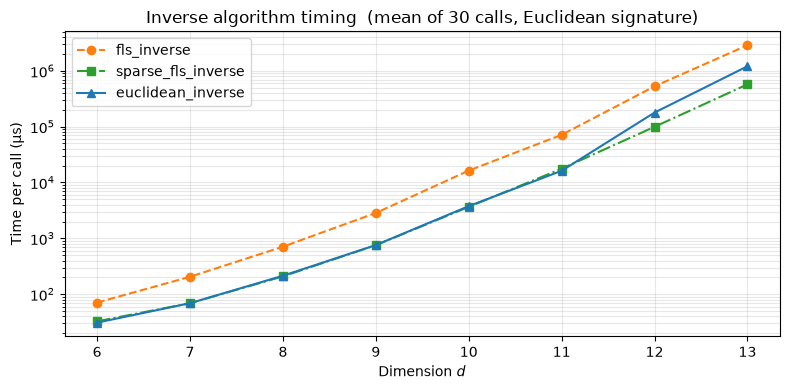

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

styles = {
    "fls":        dict(marker='o', linestyle='--', color='tab:orange', label='fls_inverse'),
    "sparse_fls": dict(marker='s', linestyle='-.',  color='tab:green',  label='sparse_fls_inverse'),
    "euclidean":  dict(marker='^', linestyle='-',   color='tab:blue',   label='euclidean_inverse'),
}

for name, style in styles.items():
    ax.semilogy(dims, results[name], **style)

ax.set_xlabel('Dimension $d$')
ax.set_ylabel('Time per call (µs)')
ax.set_title(f'Inverse algorithm timing  (mean of {N_RUNS} calls, Euclidean signature)')
ax.set_xticks(dims)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Residual conditioning sweep

Inverse quality (max residual) vs. condition number of the input multivector,
sampled at Cl(8).

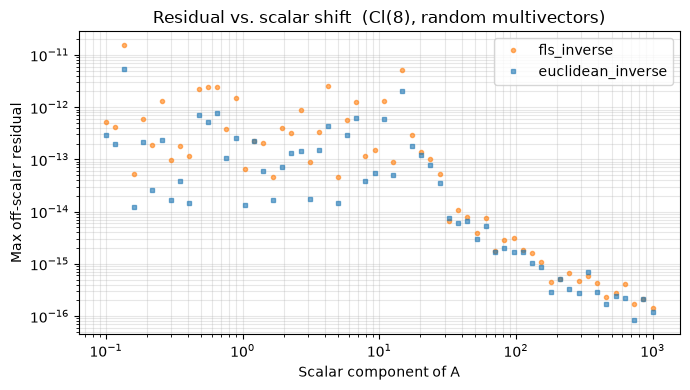

In [5]:
Cl(8)
n_samples = 60
scales = np.logspace(-1, 3, n_samples)   # scalar component from 0.1 to 1000
residuals_fls   = []
residuals_euclid = []

for s in scales:
    A = Accum(); A.random()
    A.Reg[0] = s    # shift scalar component to vary effective condition
    iA_f = fls_inverse(A)
    iA_e = euclidean_inverse(A)
    residuals_fls.append(max(abs((A * iA_f).Reg[1:])))
    residuals_euclid.append(max(abs((A * iA_e).Reg[1:])))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(scales, residuals_fls,    'o', markersize=3, color='tab:orange', alpha=0.6, label='fls_inverse')
ax.loglog(scales, residuals_euclid, 's', markersize=3, color='tab:blue',   alpha=0.6, label='euclidean_inverse')
ax.set_xlabel('Scalar component of A')
ax.set_ylabel('Max off-scalar residual')
ax.set_title('Residual vs. scalar shift  (Cl(8), random multivectors)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()